In [10]:
from asammdf import MDF 
import cantools 
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go 
from plotly.subplots import make_subplots

In [11]:

db = cantools.database.load_file(r"C:\Users\dell\Desktop\MBGP Mentoring\Programming\Excel Data\obd2-pack-v5\obd2-dbc\CSS-Electronics-11-bit-OBD2-v2.2.dbc")

print("=== Messages in DBC ===")
for message in db.messages:
    print (f"\n Message : {message.name}")
    print (f"CAN ID : {hex(message.frame_id)}")
    print (f"Length : {message.length} bytes")

    for signal in message.signals:
        print(f"\nSignal : '{signal.name}'")
        print(f"Start bit : {signal.start}")
        print(f"Bit length : {signal.length}")
        print(f"Unit : '{signal.unit}'")
        print(f"Scale/Offset : {signal.scale} / {signal.offset}")

=== Messages in DBC ===

 Message : OBD2
CAN ID : 0x7e8
Length : 8 bytes

Signal : 'Length'
Start bit : 7
Bit length : 8
Unit : 'None'
Scale/Offset : 1 / 0

Signal : 'Response'
Start bit : 15
Bit length : 4
Unit : 'None'
Scale/Offset : 1 / 0

Signal : 'Service'
Start bit : 11
Bit length : 4
Unit : 'None'
Scale/Offset : 1 / 0

Signal : 'S01PID'
Start bit : 23
Bit length : 8
Unit : 'None'
Scale/Offset : 1 / 0

Signal : 'S02PID'
Start bit : 23
Bit length : 8
Unit : 'None'
Scale/Offset : 1 / 0

Signal : 'S01PID00_PIDsSupported_01_20'
Start bit : 31
Bit length : 32
Unit : 'None'
Scale/Offset : 1 / 0

Signal : 'S01PID01_MonitorStatus'
Start bit : 31
Bit length : 32
Unit : 'None'
Scale/Offset : 1 / 0

Signal : 'S01PID02_FreezeDTC'
Start bit : 31
Bit length : 16
Unit : 'None'
Scale/Offset : 1 / 0

Signal : 'S01PID03_FuelSystemStatus'
Start bit : 31
Bit length : 16
Unit : 'None'
Scale/Offset : 1 / 0

Signal : 'S01PID04_CalcEngineLoad'
Start bit : 31
Bit length : 8
Unit : '%'
Scale/Offset : 0.39

In [12]:
mdf = MDF(r"C:\Users\dell\Desktop\MBGP Mentoring\Programming\Excel Data\obd2-pack-v5\obd2-sample-data\Renault Kadjar 2020\00000001.MF4")

raw_df = mdf.to_dataframe()
raw_df = raw_df.rename(columns={
        'CAN_DataFrame.CAN_DataFrame.ID'         : 'ID',
        'CAN_DataFrame.CAN_DataFrame.DataBytes'  : 'DataBytes',
        'CAN_DataFrame.CAN_DataFrame.DataLength' : 'DataLength',
        'CAN_DataFrame.CAN_DataFrame.Dir'        : 'Dir',
        'CAN_DataFrame.CAN_DataFrame.BusChannel' : 'BusChannel', 
        'CAN_DataFrame.CAN_DataFrame.IDE'        : 'IDE', 
        'CAN_DataFrame.CAN_DataFrame.DLC'        : 'DLC', 
        'CAN_DataFrame.CAN_DataFrame.EDL'        : 'EDL',
        'CAN_DataFrame.CAN_DataFrame.BRS'        : 'BRS'
})
print("=== Raw DataFrame Info ===")
print(f"Total frames : {len(raw_df)}")
print(f"Columns      : {list(raw_df.columns)}")
print(f"Time range   : {raw_df.index[0]:.3f}s → {raw_df.index[-1]:.3f}s")
print()

OBD2_ID = 0x7E8  
obd2_df = raw_df[raw_df['ID'] == OBD2_ID].copy()

print(f"Total frames    : {len(raw_df)}")
print(f"OBD2 frames     : {len(obd2_df)}")
print()

#Decoration 
print("=== First 10 Raw OBD2 Frames ===")
print(f"{'Timestamp':>12}   B0    B1    B2    B3    B4    B5    B6    B7")
print(f"{'':>12}   Len   Mode  PID   A     B     C     D     ")
print("-" * 75)

#Converting the databytes into hex code 
for timestamp, row in obd2_df.head(10).iterrows():
    hex_str = '  '.join(f'{b:02X}' for b in row['DataBytes'])
    print(f"{timestamp:>12.5f}s   {hex_str}")

=== Raw DataFrame Info ===
Total frames : 3077765
Columns      : ['BusChannel', 'ID', 'IDE', 'DLC', 'DataLength', 'DataBytes', 'Dir']
Time range   : 0.000s → 2068.459s

Total frames    : 3077765
OBD2 frames     : 5458

=== First 10 Raw OBD2 Frames ===
   Timestamp   B0    B1    B2    B3    B4    B5    B6    B7
               Len   Mode  PID   A     B     C     D     
---------------------------------------------------------------------------
    36.21755s   04  41  0C  00  00  AA  AA  AA
    36.51680s   03  41  0D  00  AA  AA  AA  AA
    36.81740s   04  41  10  00  00  AA  AA  AA
    37.11680s   03  41  11  E6  AA  AA  AA  AA
    37.41740s   04  41  5E  00  00  AA  AA  AA
    37.71680s   03  41  5C  3C  AA  AA  AA  AA
    38.01740s   03  41  62  7D  AA  AA  AA  AA
    38.31700s   04  41  42  2A  30  AA  AA  AA
    38.61740s   03  41  33  64  AA  AA  AA  AA
    38.91710s   03  41  04  FF  AA  AA  AA  AA


In [13]:
obd2_df

,BusChannel,ID,IDE,DLC,DataLength,DataBytes,Dir
timestamps,,,,,,,
36.21755,1.0,2024,0.0,8,8.0,"[4, 65, 12, 0, 0, 170, 170, 170]",0.0
36.51680,1.0,2024,0.0,8,8.0,"[3, 65, 13, 0, 170, 170, 170, 170]",0.0
36.81740,1.0,2024,0.0,8,8.0,"[4, 65, 16, 0, 0, 170, 170, 170]",0.0
37.11680,1.0,2024,0.0,8,8.0,"[3, 65, 17, 230, 170, 170, 170, 170]",0.0
37.41740,1.0,2024,0.0,8,8.0,"[4, 65, 94, 0, 0, 170, 170, 170]",0.0
...,...,...,...,...,...,...,...
2067.12735,1.0,2024,0.0,8,8.0,"[3, 65, 17, 231, 170, 170, 170, 170]",0.0
2067.42735,1.0,2024,0.0,8,8.0,"[4, 65, 94, 0, 41, 170, 170, 170]",0.0
2067.72730,1.0,2024,0.0,8,8.0,"[3, 65, 92, 116, 170, 170, 170, 170]",0.0


In [14]:
decoded_records = []
for timestamp, row in obd2_df.iterrows():
    raw_bytes = row["DataBytes"]
    raw_bytes = bytes(raw_bytes)

    try: 
        decoded = db.decode_message(frame_id_or_name=0x7E8, data = raw_bytes, decode_choices=False)
        
        decoded['timestamp'] = timestamp
        decoded_records.append(decoded)

    except Exception as e: 
        print (f"Could not decode frame at {timestamp:.4f}s : {e}")
        pass

print(f"Total frames    : {len(obd2_df)}")
print(f"Decoded frames  : {len(decoded_records)}")
print()

decoded_df = pd.DataFrame(decoded_records)
decoded_df = decoded_df.set_index("timestamp")

print (f"Shape : {decoded_df.shape}")
print (f"Decoded Columns : {list(decoded_df.columns)}")
print()

decoded_df

Total frames    : 5458
Decoded frames  : 5458

Shape : (5458, 18)
Decoded Columns : ['Length', 'Response', 'Service', 'S01PID', 'S01PID0C_EngineRPM', 'S01PID0D_VehicleSpeed', 'S01PID10_MAFAirFlowRate', 'S01PID11_ThrottlePosition', 'S01PID5E_EngineFuelRate', 'S01PID5C_EngineOilTemp', 'S01PID62_ActualEngTorqPct', 'S01PID42_ControlModuleVolt', 'S01PID33_AbsBaroPres', 'S01PID04_CalcEngineLoad', 'S01PID0F_IntakeAirTemperature', 'S01PID2F_FuelTankLevel', 'S01PID05_EngineCoolantTemp', 'S01PID0B_IntakeManiAbsPress']



,Length,Response,Service,S01PID,S01PID0C_EngineRPM,S01PID0D_VehicleSpeed,S01PID10_MAFAirFlowRate,S01PID11_ThrottlePosition,S01PID5E_EngineFuelRate,S01PID5C_EngineOilTemp,S01PID62_ActualEngTorqPct,S01PID42_ControlModuleVolt,S01PID33_AbsBaroPres,S01PID04_CalcEngineLoad,S01PID0F_IntakeAirTemperature,S01PID2F_FuelTankLevel,S01PID05_EngineCoolantTemp,S01PID0B_IntakeManiAbsPress
timestamp,,,,,,,,,,,,,,,,,,
36.21755,4,4,1,12,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36.51680,3,4,1,13,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36.81740,4,4,1,16,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37.11680,3,4,1,17,NaN,NaN,NaN,90.19680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37.41740,4,4,1,94,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2067.12735,3,4,1,17,NaN,NaN,NaN,90.58896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2067.42735,4,4,1,94,NaN,NaN,NaN,NaN,2.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2067.72730,3,4,1,92,NaN,NaN,NaN,NaN,NaN,76.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
id_counts = raw_df['ID'].value_counts()

print("=== CAN IDs in file (decimal → hex : frame count) ===")
for dec_id, count in id_counts.items():
    print(f"  {dec_id:>6} >> {hex(dec_id):>8}  :  {count} frames")

=== CAN IDs in file (decimal → hex : frame count) ===
     786 >>    0x312  :  206848 frames
     224 >>     0xe0  :  206848 frames
     225 >>     0xe1  :  206848 frames
     346 >>    0x15a  :  194614 frames
     348 >>    0x15c  :  194614 frames
     349 >>    0x15d  :  194614 frames
     350 >>    0x15e  :  194614 frames
     413 >>    0x19d  :  187346 frames
     665 >>    0x299  :  103424 frames
     705 >>    0x2c1  :  103424 frames
     478 >>    0x1de  :  103424 frames
     666 >>    0x29a  :  103424 frames
     855 >>    0x357  :  103424 frames
     548 >>    0x224  :  103391 frames
     916 >>    0x394  :  97307 frames
     759 >>    0x2f7  :  51711 frames
     888 >>    0x378  :  41175 frames
    1108 >>    0x454  :  21275 frames
    1104 >>    0x450  :  21230 frames
    1112 >>    0x458  :  20923 frames
    1107 >>    0x453  :  20733 frames
    1113 >>    0x459  :  20687 frames
    1106 >>    0x452  :  20687 frames
    1246 >>    0x4de  :  20686 frames
    1102 >>    0x44e

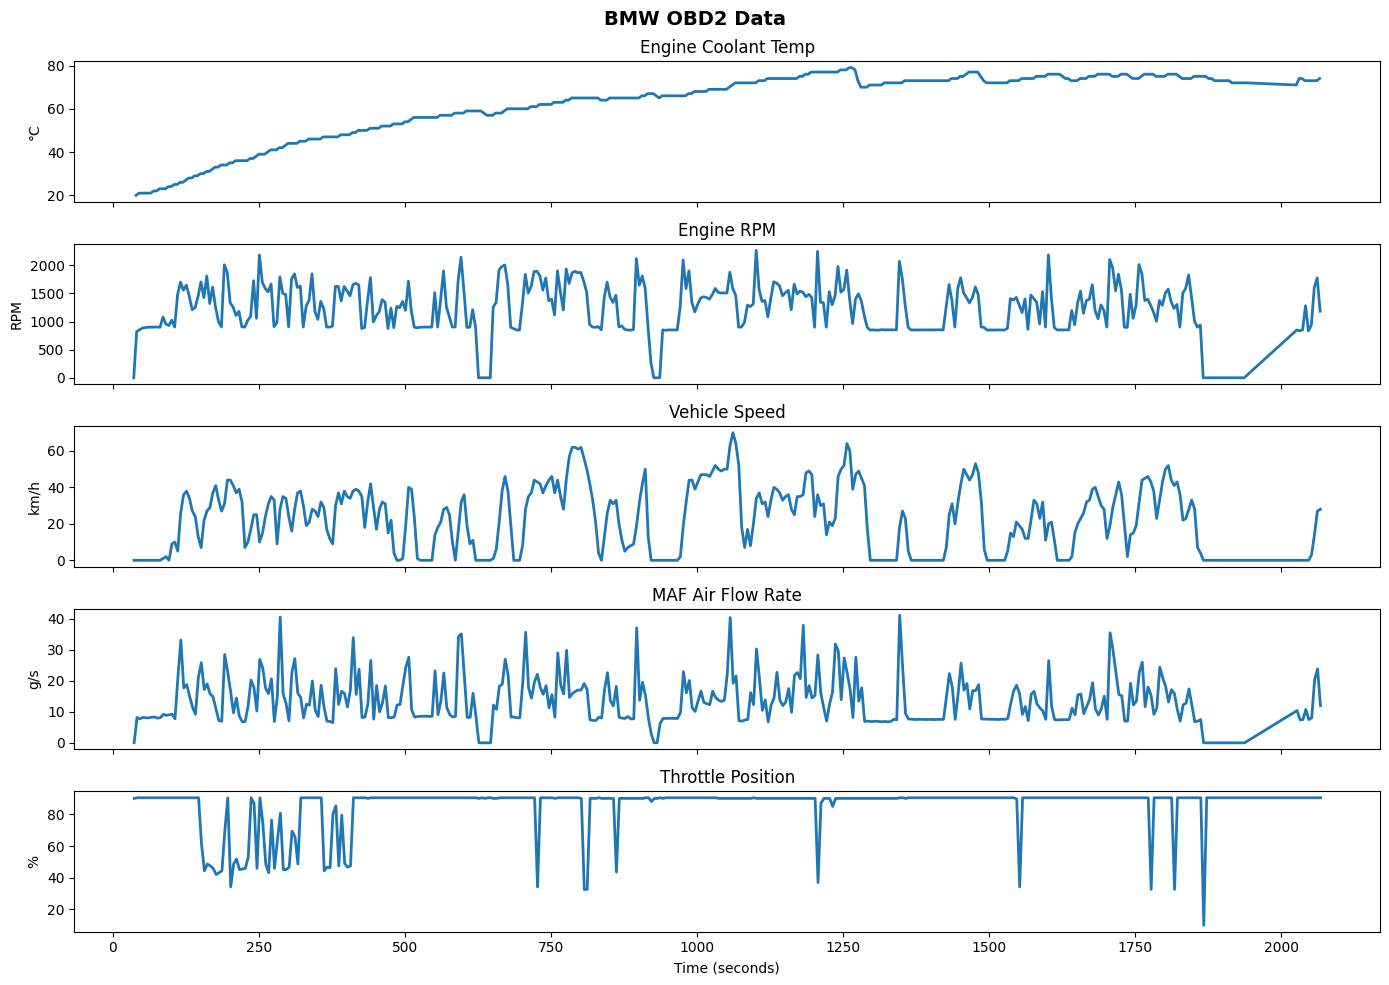

In [16]:
signals_to_plot = [
    'S01PID05_EngineCoolantTemp',
    'S01PID0C_EngineRPM',
    'S01PID0D_VehicleSpeed',
    'S01PID10_MAFAirFlowRate',
    'S01PID11_ThrottlePosition'
]

signal_series = {}
for signal in signals_to_plot: 
    series = decoded_df[signal].dropna()
    signal_series[signal] = series
    # print(f"{signal:45} -- {len(series)} samples")

print()

#Creating subplots 

fig, axes = plt.subplots(
    nrows=len(signals_to_plot),
    ncols = 1,
    figsize = (14,10),
    sharex = True
)

fig.suptitle("BMW OBD2 Data", fontsize = 14, fontweight = "bold")
plt.rcParams['axes.grid'] = True

units = {
    'S01PID05_EngineCoolantTemp' : '°C',
    'S01PID0C_EngineRPM'         : 'RPM',
    'S01PID0D_VehicleSpeed'      : 'km/h',
    'S01PID10_MAFAirFlowRate'    : 'g/s',
    'S01PID11_ThrottlePosition'  : '%'
}

titles = {
    'S01PID05_EngineCoolantTemp' : 'Engine Coolant Temp',
    'S01PID0C_EngineRPM'         : 'Engine RPM',
    'S01PID0D_VehicleSpeed'      : 'Vehicle Speed',
    'S01PID10_MAFAirFlowRate'    : 'MAF Air Flow Rate',
    'S01PID11_ThrottlePosition'  : 'Throttle Position'
}

for i, signal in enumerate(signals_to_plot):
    ax = axes[i]
    series = signal_series[signal]

    ax.plot(series.index,series.values, linewidth = 2)
    ax.set_ylabel(units[signal])
    ax.set_title(titles[signal])

axes[-1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()

In [17]:
#Quick Stats of the decoeded dataframe with .describe()

for sig_name, unit in units.items():
    signal_stats = decoded_df[sig_name].dropna().describe()
    
    print (signal_stats)
    print()

count    390.000000
mean      62.384615
std       15.162556
min       20.000000
25%       56.000000
50%       68.000000
75%       74.000000
max       79.000000
Name: S01PID05_EngineCoolantTemp, dtype: float64

count     390.000000
mean     1209.006410
std       473.160983
min         0.000000
25%       897.625000
50%      1266.000000
75%      1526.250000
max      2266.500000
Name: S01PID0C_EngineRPM, dtype: float64

count    390.000000
mean      22.587179
std       17.931929
min        0.000000
25%        2.000000
50%       23.000000
75%       36.750000
max       70.000000
Name: S01PID0D_VehicleSpeed, dtype: float64

count    390.000000
mean      13.283282
std        7.724015
min        0.000000
25%        7.695000
50%       11.805000
75%       17.390000
max       41.170000
Name: S01PID10_MAFAirFlowRate, dtype: float64

count    390.000000
mean      85.317927
std       14.546618
min        9.804000
25%       90.196800
50%       90.588960
75%       90.588960
max       90.588960
Name: S0

In [21]:
#Saving the decoded dataframe as a CSV 

output_path = r"C:\Users\dell\Desktop\MBGP Mentoring\Programming\Excel Data\Decoded files\RenaultKadjar_obd2_decoded.csv"

decoded_df.to_csv(output_path)

print(f"Saved to : {output_path}")
print (f"Number of rows: {len(decoded_df)}")
print (f"Columns : {list(decoded_df.columns)}")

Saved to : C:\Users\dell\Desktop\MBGP Mentoring\Programming\Excel Data\Decoded files\RenaultKadjar_obd2_decoded.csv
Number of rows: 5458
Columns : ['Length', 'Response', 'Service', 'S01PID', 'S01PID0C_EngineRPM', 'S01PID0D_VehicleSpeed', 'S01PID10_MAFAirFlowRate', 'S01PID11_ThrottlePosition', 'S01PID5E_EngineFuelRate', 'S01PID5C_EngineOilTemp', 'S01PID62_ActualEngTorqPct', 'S01PID42_ControlModuleVolt', 'S01PID33_AbsBaroPres', 'S01PID04_CalcEngineLoad', 'S01PID0F_IntakeAirTemperature', 'S01PID2F_FuelTankLevel', 'S01PID05_EngineCoolantTemp', 'S01PID0B_IntakeManiAbsPress']


In [22]:
fig = make_subplots(
    rows = 5, 
    cols= 1, 
    shared_xaxes= False, 
    subplot_titles= ('Engine Coolant Temp (°C)', 
    'Engine RPM (RPM)', 
    'Vehicle Speed (km/h)', 
    'MAF Air Flow Rate (g/s)',
    'Throttle Position (%)'), 
    vertical_spacing= 0.1, 
)
signal_config = [
    ('S01PID05_EngineCoolantTemp', 1, 'red'),  
    ('S01PID0C_EngineRPM',         2, 'blue'),  
    ('S01PID0D_VehicleSpeed',      3, 'green'),  
    ('S01PID10_MAFAirFlowRate',    4, 'yellow'),  
    ('S01PID11_ThrottlePosition',  5, 'purple'),  
]

for sig_name, row, colour in signal_config:
    sig_data = decoded_df[sig_name].dropna()

    fig.add_trace(go.Scatter(
        x = sig_data.index, 
        y = sig_data.values, 
        mode = 'lines', 
        name = sig_name, 
        line = dict(color = colour, width = 1),
        showlegend= True
    ), 
    row = row, 
    col = 1 )

fig.update_layout( 
    title = "Renault Kadjar OBD2 Plot (interactive)", 
    height = 900, 
    width = 1200, 
    plot_bgcolor = "white",
    paper_bgcolor = "white", 
    showlegend = True
)

fig.update_xaxes(title_text = "Time (seconds)", row = 5, col = 1)
fig.update_xaxes(showline=True, linewidth=0.5, linecolor='black', gridcolor = "lightgrey", gridwidth = 0.25)
fig.update_yaxes(showline=True, linewidth=0.5, linecolor='black', gridcolor = "lightgrey", gridwidth = 0.25, layer = "below traces" )

fig.show()